In [1]:
import sys
import json
import imageio
import numpy as np
import seaborn as sns
from scipy.stats import linregress   
import matplotlib as mpl
import matplotlib.pyplot as plt

sys.path.append("scripts/utils")
from Microscopes    import Holomonitor, Tomocube
from SegmentedCells import SegmentedCells
from averaging_functions import bin_data_by_density, weighted_average
from variation_functions import compute_temporal_variation


data_path = "../../../../hdd_data/silja/Monolayers/"

In [2]:
dt = 1
parameter = 'h'      # A or h
measure   = "disc"   # cell, disk or pixel
binsize   = 200
variable  = "t"      # r, t, or both


In [3]:
datasets = [
            "MDCK_20240301_B1-4",
            "MDCK_20240301_B2-2",
            "MDCK_20240301_B2-6",
            "MDCK_20240317_B1-1",
            "MDCK_20240319_A1-9",
            "MDCK_20240319_A1-13",
            "MDCK_20240319_A1-16",
            "MDCK_20240319_A1-18",
            "MDCK_20240319_B1-11",
            "MDCK_20240516_A2-1",
            "MDCK_20240516_A2-7",
            "MDCK_20240516_B1-9",
            "MDCK_20240516_B1-13",
            "MDCK_20240516_B1-22",
            "MDCK_20250210_A2-1",
            "MDCK_20250904_B1-1"
            ]

np.sum(1)

np.int64(1)

In [4]:
if variable == "t":

    # compute temporal variation
    hmean_tmp, hstd_tmp, mean, rho_tmp = compute_temporal_variation(datasets, 
                                                            measure=measure,
                                                            parameter=parameter, 
                                                            dt=dt)

h_mean = mean
h_variation_mean = hmean_tmp
h_variation_std  = hstd_tmp
cell_densities   = rho_tmp


State loaded from ../../../../hdd_data/silja/Monolayers//cell_features/calibrated/MDCK_20240301_B1-4_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers//cell_features/calibrated/MDCK_20240301_B1-4_cells.p.


  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:23<00:00,  3.35s/it]


State loaded from ../../../../hdd_data/silja/Monolayers//cell_features/calibrated/MDCK_20240301_B2-2_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers//cell_features/calibrated/MDCK_20240301_B2-2_cells.p.


100%|██████████| 1/1 [00:03<00:00,  3.24s/it]


...

100%|██████████| 5/5 [00:21<00:00,  4.36s/it]


State loaded from ../../../../hdd_data/silja/Monolayers//cell_features/calibrated/MDCK_20250210_A2-1_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers//cell_features/calibrated/MDCK_20250210_A2-1_cells.p.


100%|██████████| 6/6 [05:00<00:00, 50.03s/it]


State loaded from ../../../../hdd_data/silja/Monolayers//cell_features/calibrated/MDCK_20250904_B1-1_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers//cell_features/calibrated/MDCK_20250904_B1-1_cells.p.


100%|██████████| 6/6 [06:19<00:00, 63.17s/it]


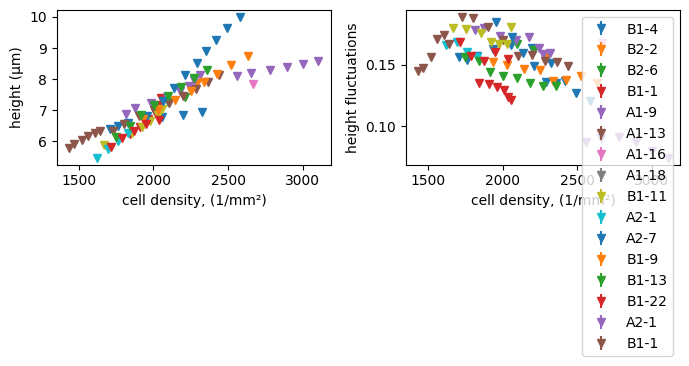

In [5]:
fig, ax = plt.subplots(1,2, figsize=(7,3))

# plot spatial variation
# Holomonitor
for rho, mean, hmean, hstd, dataset in zip(cell_densities,
                            h_mean, 
                            h_variation_mean, 
                            h_variation_std,
                            datasets):
    ax[0].plot(rho, mean, 'v')
    ax[1].errorbar(rho, hmean, yerr=hstd, fmt="v", label=dataset.split("_")[-1])

ax[0].set(
    xlabel="cell density, (1/mm²)",
    ylabel="height (µm)");
            

ax[1].set(
    xlabel="cell density, (1/mm²)",
    ylabel="height fluctuations");

ax[1].legend()
fig.tight_layout()


In [6]:
# Define dishes to take technical averages over
dishes = [
          "MDCK_20240301_B1",
          "MDCK_20240301_B2", 
          "MDCK_20240317_B1", 
          "MDCK_20240319_A1", 
          "MDCK_20240319_B1", 
          "MDCK_20240516_A2", 
          "MDCK_20240516_B1", 
          "MDCK_20250210_A2", 
          "MDCK_20250904_B1",
          ]

# Define range of cell densities to bin data by
min_density = 100 * int(min(np.concatenate(cell_densities)) / 100)
max_density = 100 * int(max(np.concatenate(cell_densities)) / 100)
binned_densities = np.arange(min_density, max_density + binsize, binsize)
binned_densities = np.arange(min_density, max_density, binsize)

/tmp/ipykernel_68845/4080217212.py:43: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(binned_densities, mean, '.', label=dish.split("_")[1:3])


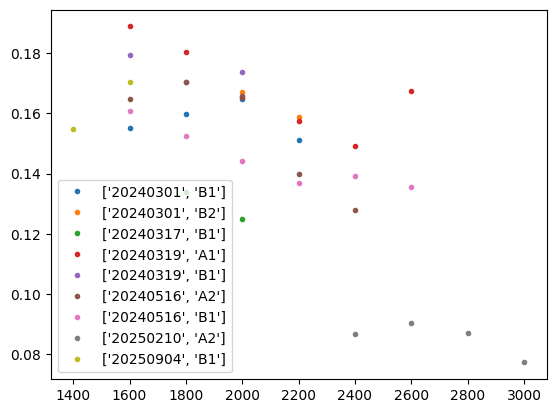

In [7]:
# Bin data and take unweighted average of technical replicates

dish_mean = []
dish_std  = []

# Loop over unique petri dishes
for dish in dishes:
    mean_arr = []
    std_arr  = []
    density_arr = []

    # Loop through techincal replicates in dish
    for dataset, mean, std, rho in zip(datasets, h_variation_mean, h_variation_std, cell_densities):

        # add data to temporary array to be fed to bin_data_by_density
        if dish in dataset:
            mean_arr.append(mean)
            std_arr.append(std)
            density_arr.append(rho)

    # adapt input to function
    mean_arr = np.concatenate(mean_arr)
    std_arr  = np.concatenate(std_arr) 
    density_arr = np.concatenate(density_arr)

    # bin data
    hmean_tmp, hstd_tmp, counts = bin_data_by_density(mean_arr,
                                                        std_arr, 
                                                        density_arr, 
                                                        bin_range=[min_density, max_density], 
                                                        bin_size=binsize,
                                                        weighted=False)


    dish_mean.append(hmean_tmp)
    dish_std.append(hstd_tmp)


dish_mean = np.ma.array(dish_mean, mask=np.array(dish_mean) == 0)
dish_std  = np.ma.array(dish_std,  mask=np.array(dish_mean) == 0)

for mean, std, dish in zip(dish_mean, dish_std, dishes):
    plt.plot(binned_densities, mean, '.', label=dish.split("_")[1:3])

plt.legend()

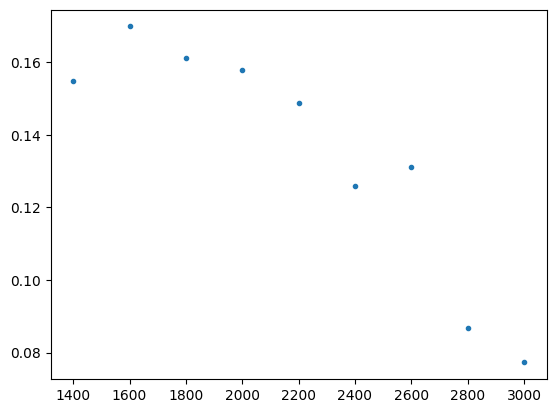

In [8]:
htmean = np.ma.mean(dish_mean, axis=0)
htstd  = np.ma.std(dish_mean, axis=0) / np.sqrt(np.sum(~dish_std.mask))
densityt = binned_densities

plt.plot(densityt, htmean, '.')

State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240301_B1-4_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240301_B2-2_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240301_B2-6_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240317_B1-1_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-9_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-13_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-16_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-18_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_B1-11_cells.p.
State loaded fr

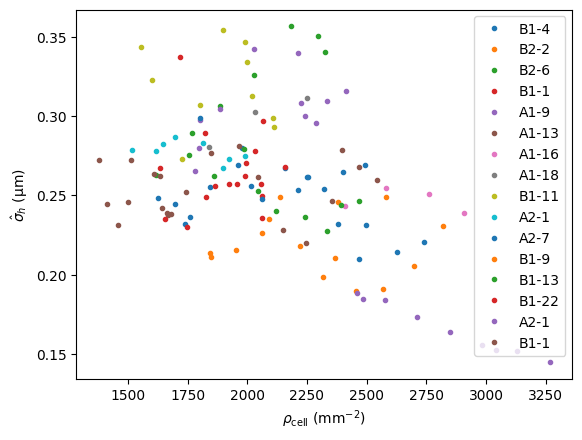

In [9]:
#density_bin = 200       # size of density bin (1/mm^2)
dt_bin    = 1           # size of temporal bin (h) 


# Load height averages, std, and corersponding cell density
mean_variation = []
std_variation  = []

densities = []

for dataset in datasets:

    config =  json.load(open(f"configs/{dataset}.json"))
    cells  = SegmentedCells(f"{data_path}cell_features/calibrated/{dataset}_cells.p")

    ### SET MICROSCOPE ###
    if config['microscope'] == "holomonitor": microscope = Holomonitor()
    elif config['microscope'] == "tomocube":  microscope = Tomocube()

    h_mean = np.load(f"data/mean_evolutions/{dataset}_h_{measure}_mean.npy")
    h_std  = np.load(f"data/mean_evolutions/{dataset}_h_{measure}_std.npy")
    h_relstds = h_std / h_mean
    
    density_tmp = cells.density

    # taking average of dt consecutive frames
    dt    = int(dt_bin / microscope.frame_to_h)
    Nbins = (len(h_mean) // dt)

    mean_variation.append(np.array(h_relstds)[: Nbins*dt].reshape(Nbins, dt).mean(axis=1))
    std_variation .append(np.array(h_relstds)[: Nbins*dt].reshape(Nbins, dt).std(axis=1, ddof=1) / np.sqrt(dt))
    densities.append(np.array(density_tmp)[: Nbins*dt].reshape(Nbins, dt).mean(axis=1).round(0))



# Plot averages of every dataset
for rho, h, dataset in zip(densities, mean_variation, datasets):
    plt.plot(rho, h, '.', label=dataset.split("_")[-1])


plt.xlabel(r"$\rho_{\text{cell}}$ (mm$^{-2}$)")
plt.ylabel(r"$\hat{\sigma}_h$ (µm)")
plt.legend();

In [10]:
# # Define range of cell densities to bin data by
# min_density = 100 * int(min(np.concatenate(densities)) / 100)
# max_density = 100 * int(max(np.concatenate(densities)) / 100)
# binned_densities = np.arange(min_density, max_density + density_bin, density_bin)
# binned_densities = np.arange(min_density, max_density, density_bin)

/tmp/ipykernel_68845/2932342842.py:42: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(binned_densities, mean, '.', label=dish.split("_")[1:3])


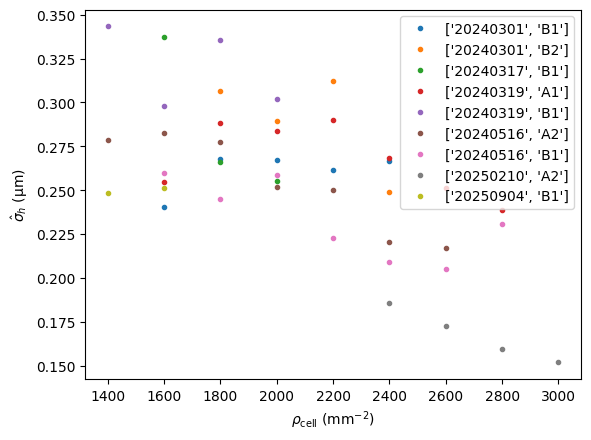

In [11]:
# Bin data and take unweighted average of technical replicates

dish_mean = []
dish_std  = []

# Loop over unique petri dishes
for dish in dishes:
    mean_arr = []
    std_arr  = []
    density_arr = []

    # Loop through techincal replicates in dish
    for dataset, mean, std, rho in zip(datasets, mean_variation, std_variation, densities):

        # add data to temporary array to be fed to bin_data_by_density
        if dish in dataset:
            mean_arr.append(mean)
            std_arr.append(std)
            density_arr.append(rho)

    # adapt input to function
    mean_arr = np.concatenate(mean_arr)
    std_arr  = np.concatenate(std_arr) 
    density_arr = np.concatenate(density_arr)

    # bin data
    hmean_tmp, hstd_tmp, counts = bin_data_by_density(mean_arr,
                                                      std_arr, 
                                                      density_arr, 
                                                      bin_range=[min_density, max_density], 
                                                      bin_size=binsize,
                                                      weighted=False)

    dish_mean.append(hmean_tmp)
    dish_std.append(hstd_tmp)


dish_mean = np.ma.array(dish_mean, mask=np.array(dish_mean) == 0)
dish_std  = np.ma.array(dish_std,  mask=np.array(dish_mean) == 0)

for mean, std, dish in zip(dish_mean, dish_std, dishes):
    plt.plot(binned_densities, mean, '.', label=dish.split("_")[1:3])


try:    
    plt.plot(binned_densities[:-1], fit.intercept + fit.slope * binned_densities[:-1], "--", c="k", lw=2)
except:
    None
    
plt.xlabel(r"$\rho_{\text{cell}}$ (mm$^{-2}$)")
plt.ylabel(r"$\hat{\sigma}_h$ (µm)")
plt.legend();

In [12]:
hrmean = np.ma.mean(dish_mean, axis=0)
hrstd  = np.ma.std(dish_mean, axis=0) / np.sum(~dish_mean.mask, axis=0)
densityr = binned_densities

In [13]:
ht_fit = linregress(densityt, htmean)
ht_fit = densityt * ht_fit.slope + ht_fit.intercept

hr_fit = linregress(densityr, hrmean)
hr_fit = densityr * hr_fit.slope + hr_fit.intercept

ht_fit

array([0.17831613, 0.1674585 , 0.15660087, 0.14574323, 0.1348856 ,
       0.12402797, 0.11317034, 0.1023127 , 0.09145507])

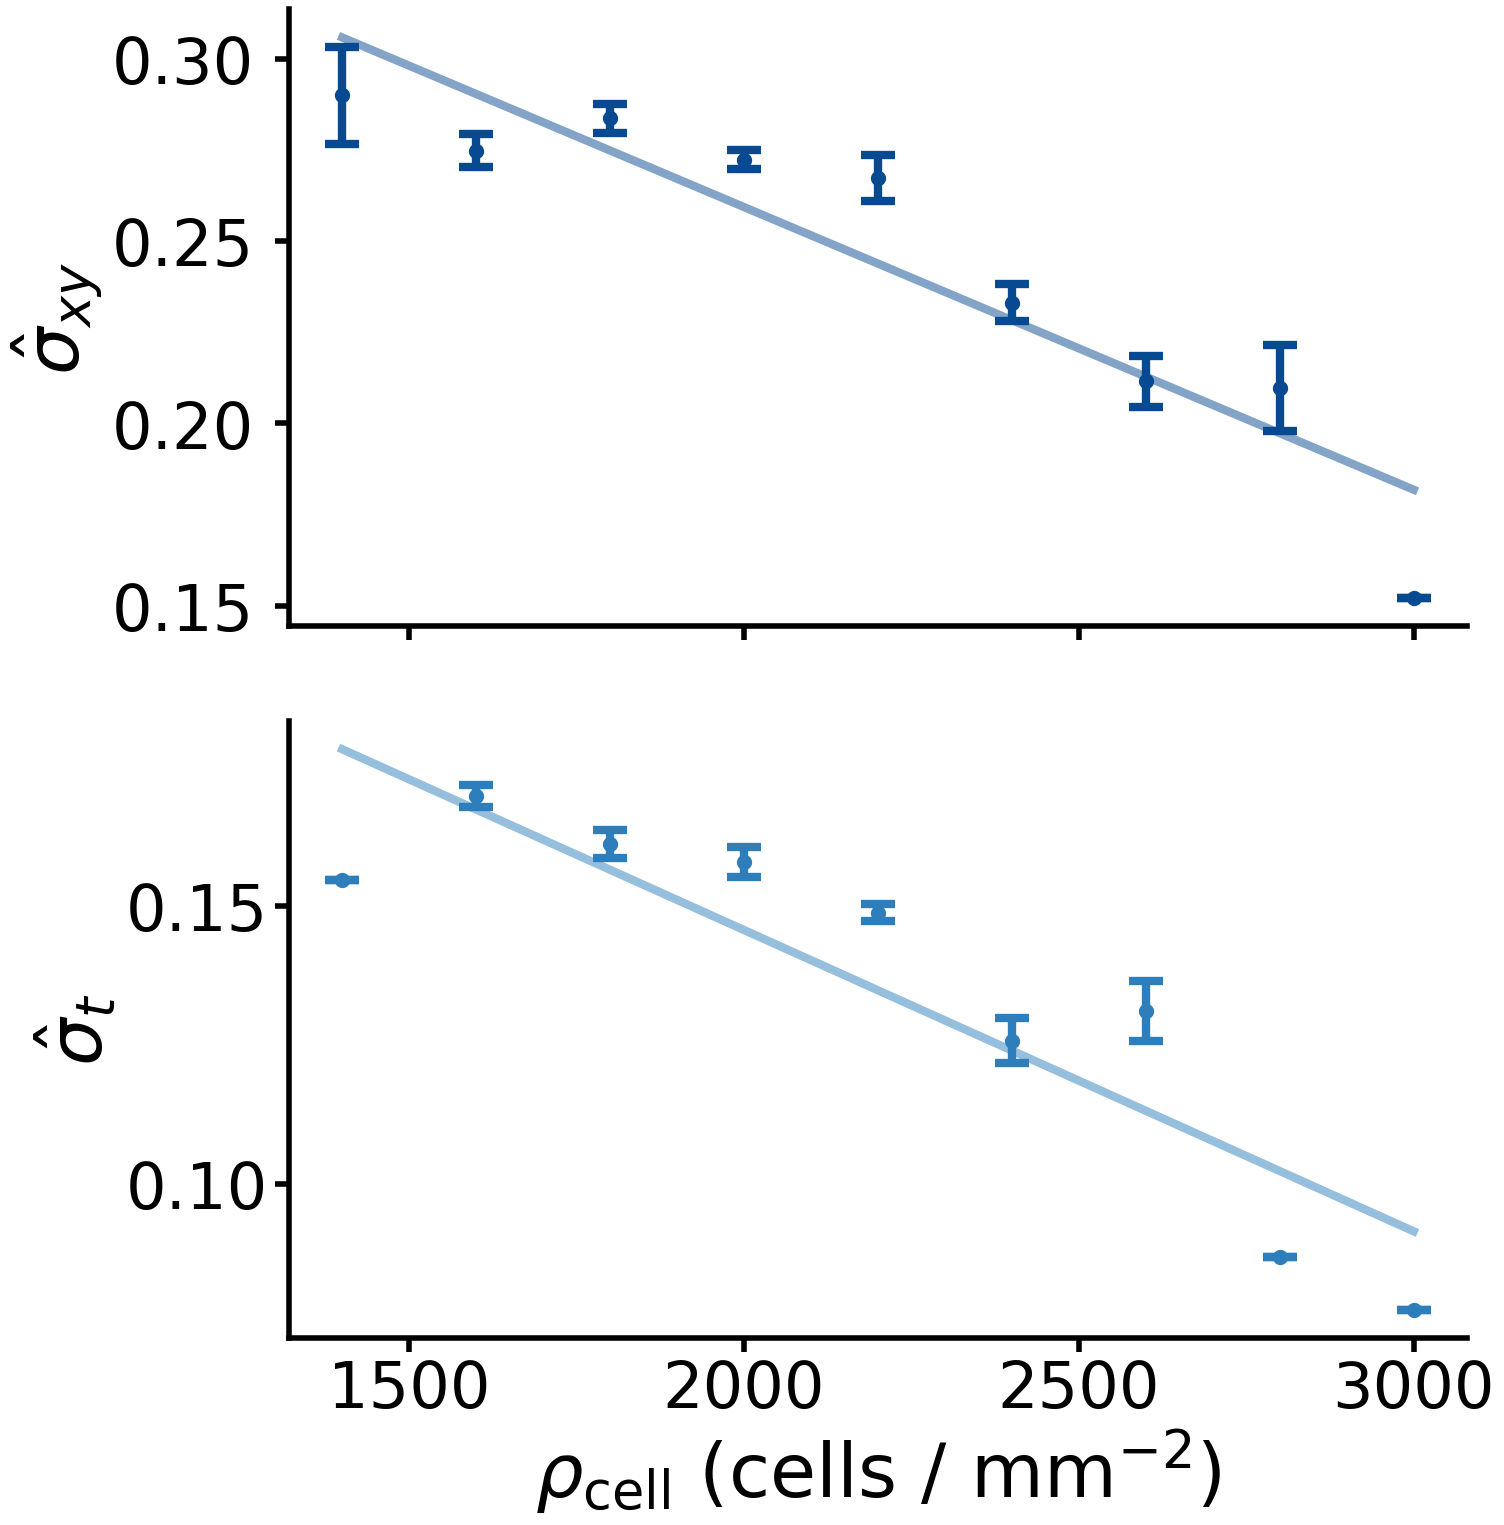

In [14]:
colors = mpl.colormaps["Blues_r"](np.linspace(0.1, 0.3, 2))

mm = 0.1 / 2.54  # centimeters in inches
font  = {'size' : 54}
lines = {'lw': 6}
axes  = {'lw': 4}
xticks = {'width': 4}
mpl.rc('font',  **font)
mpl.rc('lines', **lines)
mpl.rc('axes',  **axes)

# before the call to subplot
plt.rc('font', weight ='normal')
plt.rc('xtick.major', size = 10, pad = 5, width=4)
plt.rc('ytick.major', size = 10, pad = 5, width=4)
plt.rc('xtick', labelsize = 46)
plt.rc('ytick', labelsize = 46)

# Plot
fig, ax = plt.subplots(2,1, figsize=(398*mm, 398*mm), sharex=True, sharey=False)
ax[0].tick_params(axis='y', which='major', pad=15)
fig.subplots_adjust(left   = 8.5/35,
                    right  = 0.995,
                    top    = 0.995,
                    bottom = 5/34,
                    hspace = 2/13)

ax[0].plot(densityr, 
         hr_fit,
         "-", c=colors[0], alpha=0.5)

ax[1].plot(densityt, 
         ht_fit,
         "-", c=colors[1], alpha=0.5)


ax[0].errorbar(densityr, 
             hrmean, 
             hrstd, 
             color=colors[0], fmt=".", ms=10, fillstyle="none", markeredgewidth=6,
             capsize=12, capthick=6)

ax[1].errorbar(densityt, 
             htmean, 
             htstd, 
             color=colors[1], fmt=".", ms=10, fillstyle="none", markeredgewidth=6,
             capsize=12, capthick=6)

ax[0].set(ylabel=r"$\hat{\sigma}_{xy}$",
          #ylim=(0, .5)
          )
ax[1].set(ylabel=r"$\hat{\sigma}_{t}$",
          xlabel=r"$\rho_{\text{cell}}$ (cells$~/~$mm$^{-2}$)"
          #ylim=(0, 0.5)
          )


for axi in ax:
    axi.spines['right'].set_visible(False)
    axi.spines['top'].set_visible(False)

# fig.tight_layout()#
# fig.savefig(f"figs/Elife/subfigures/{measure}wise_height_variation.svg")